# Analysis of Inside Out 2 
Script Analysis // Text Analysis 

In [5]:
## Import Libraries and Data
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("textblob.csv", header=0, sep=",", encoding="utf-8")

In [6]:
##Explore frequency of characters
df['character'].value_counts()

character
JOY                            224
ANXIETY                        141
DISGUST                         95
ANGER                           78
RILEY                           77
                              ... 
BIG MIND COP                     1
RILEY ANDERSEN'S 1ST BELIEF      1
RILEY ANDERSEN'S 3RD BELIEF      1
GRACE'S ANGER                    1
ALL                              1
Name: count, Length: 92, dtype: int64

C:\Users\camer\AppData\Local\Temp\ipykernel_7988\3893671077.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = character_df.groupby('group')['TextBlob_polarity'].mean()


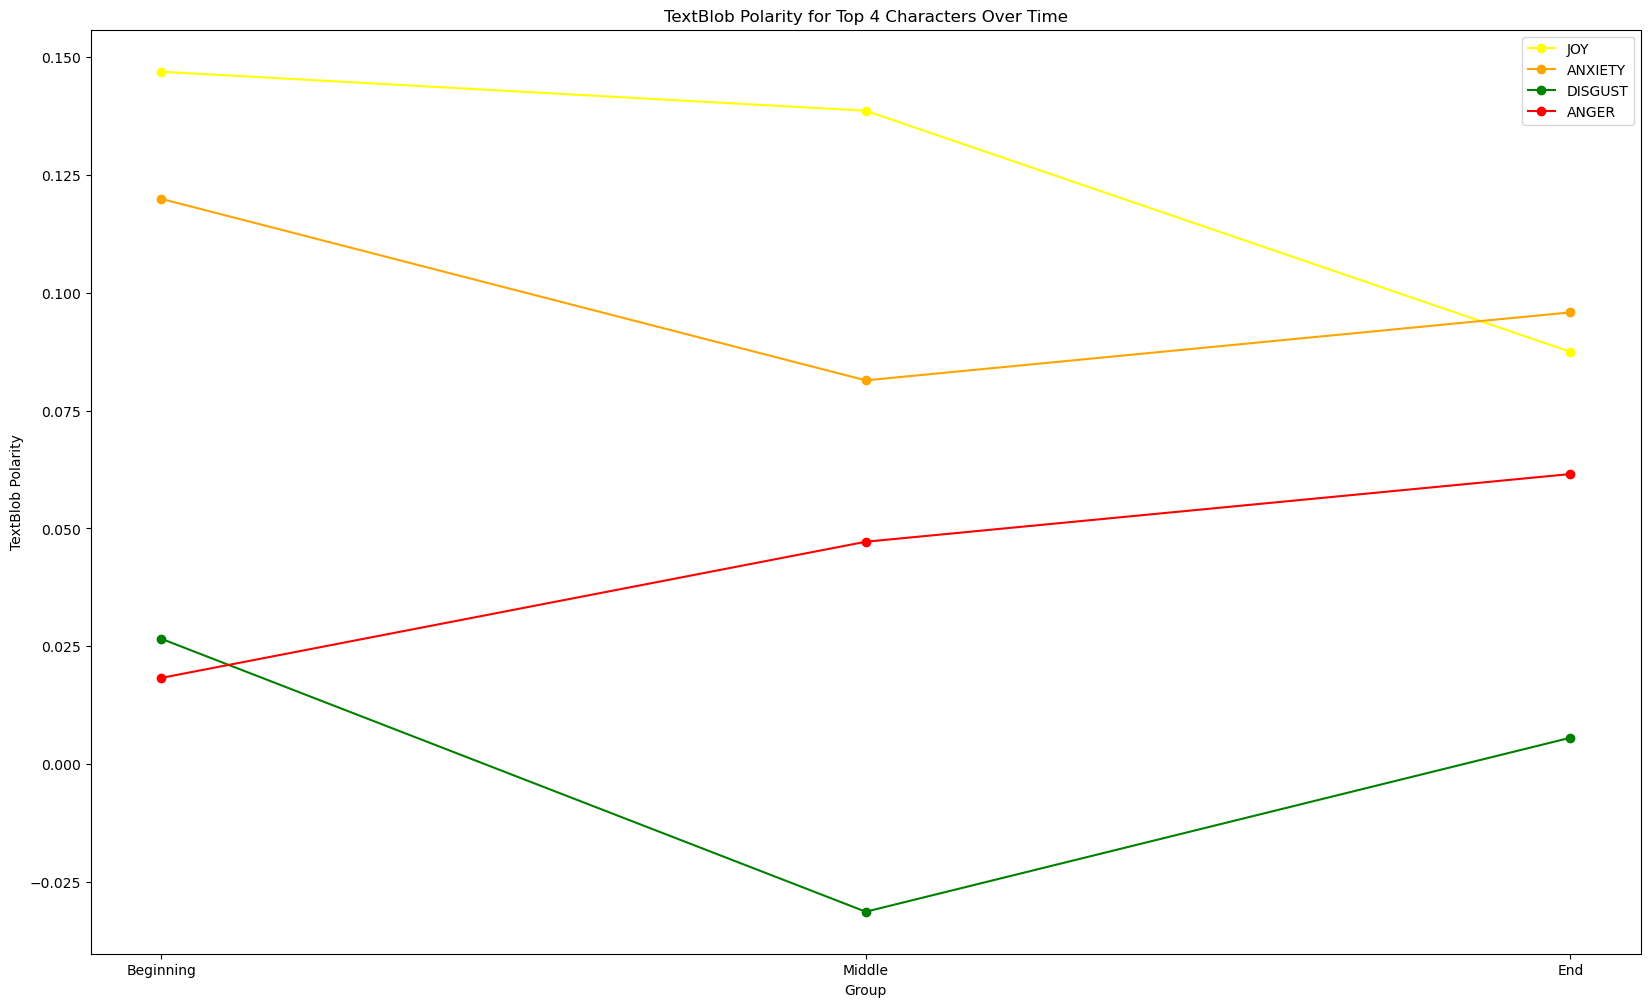

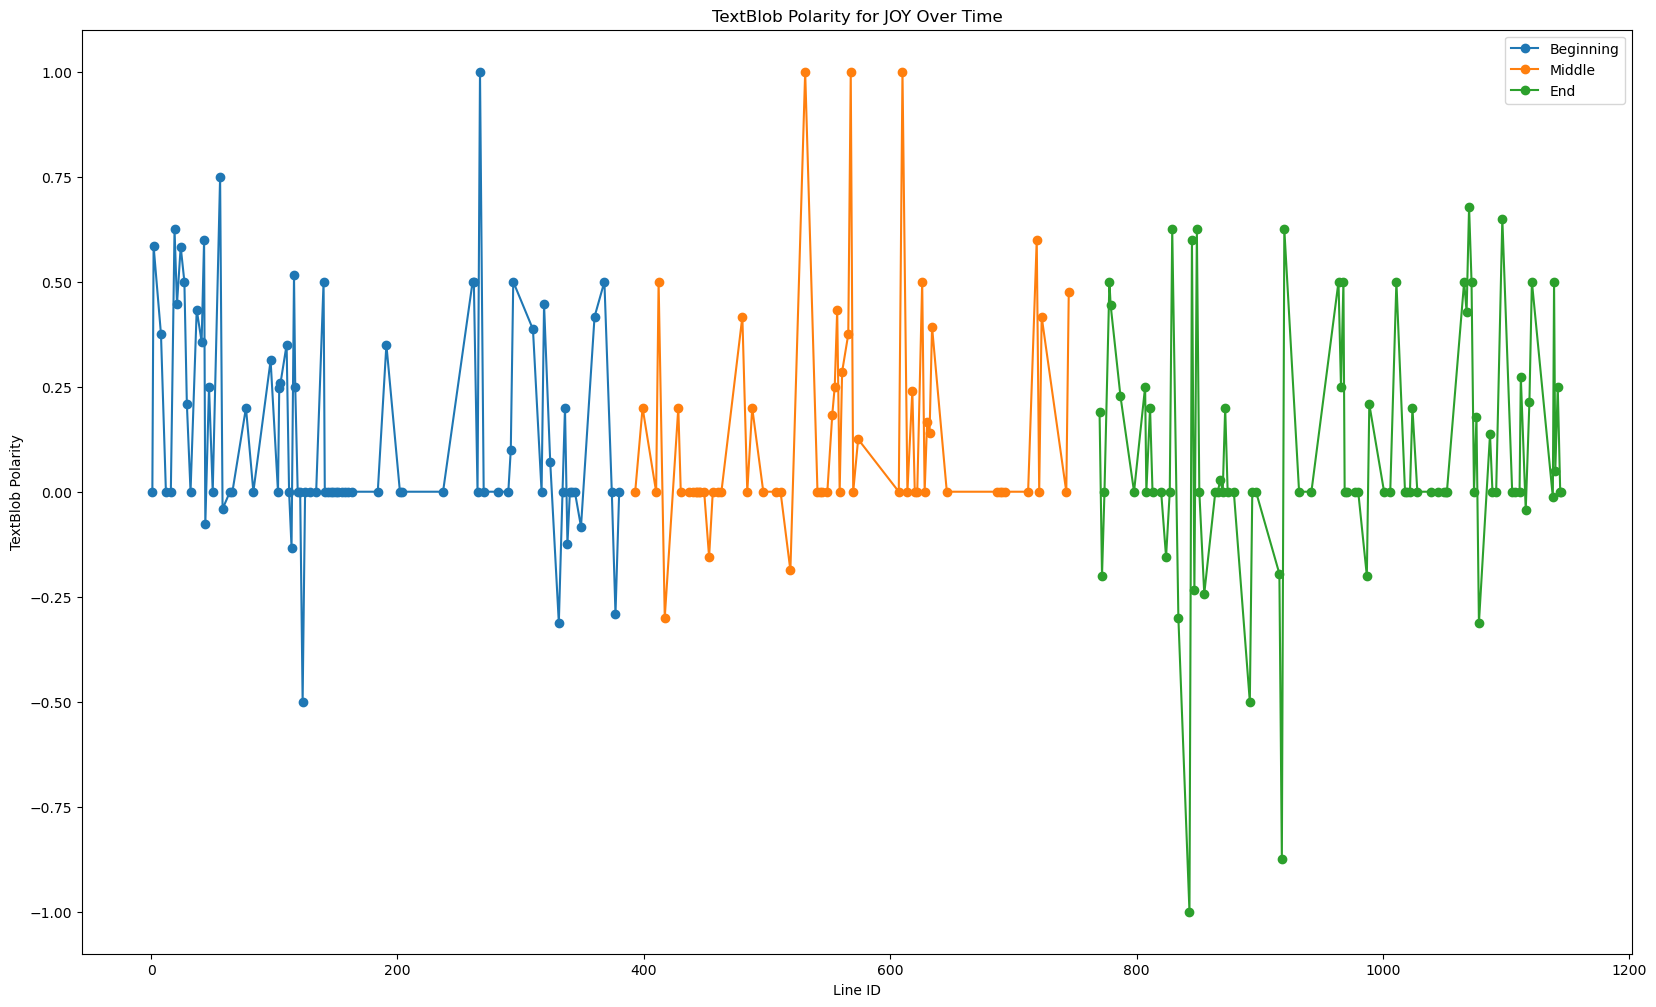

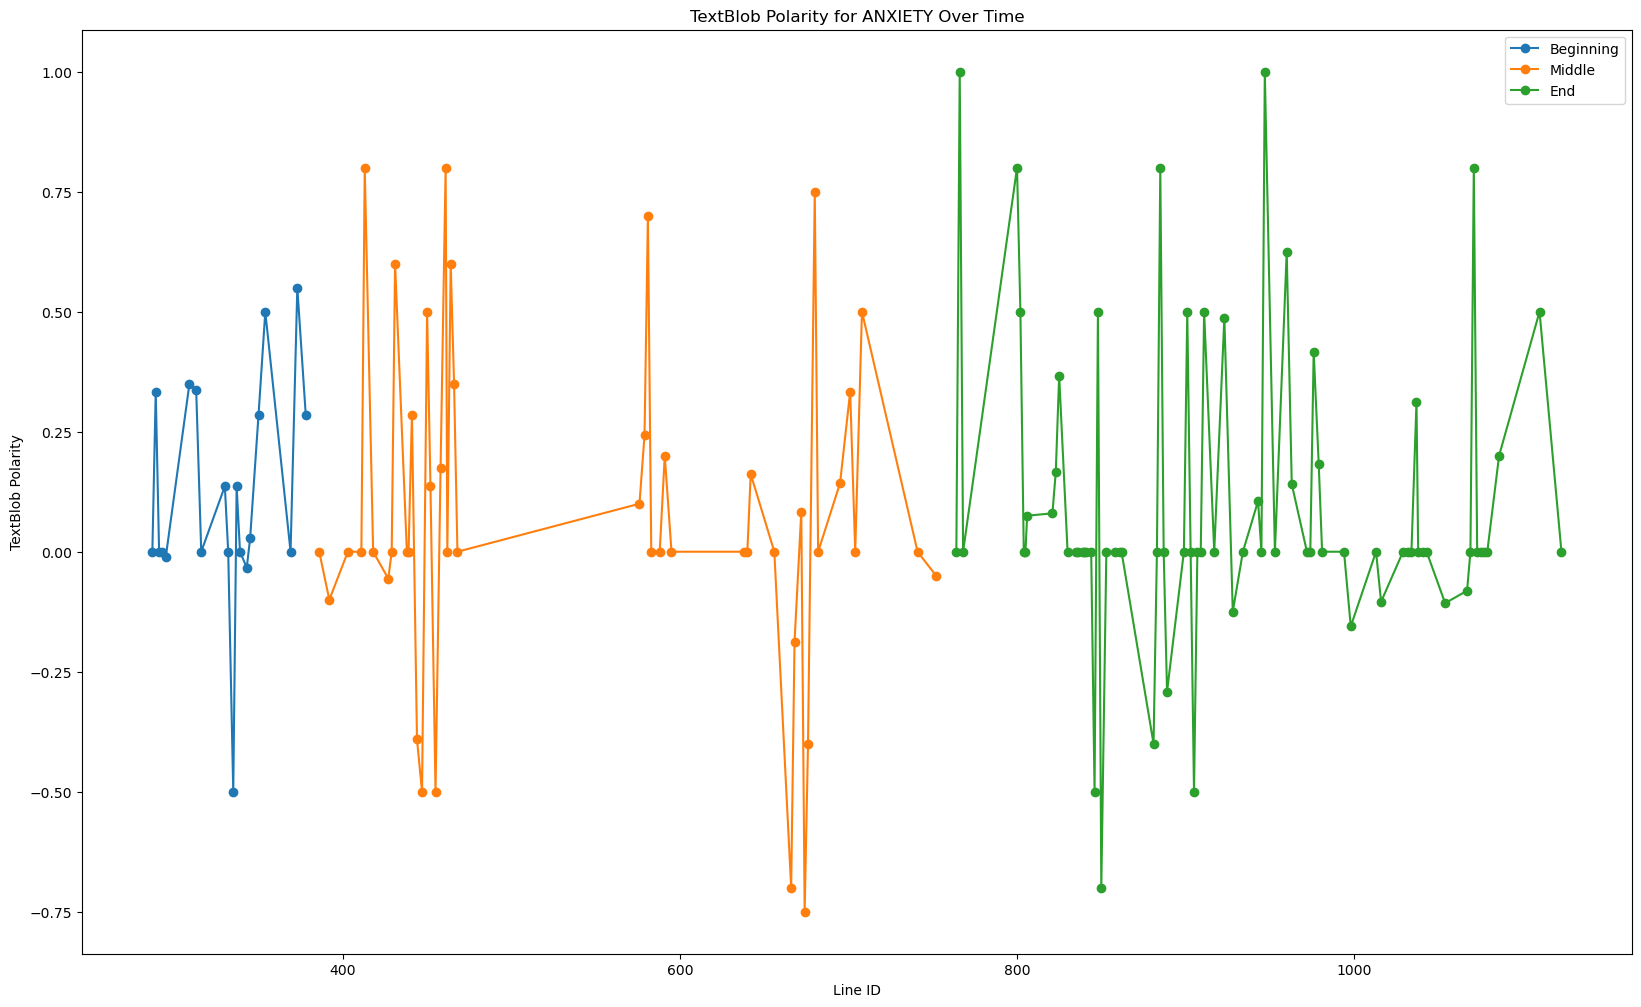

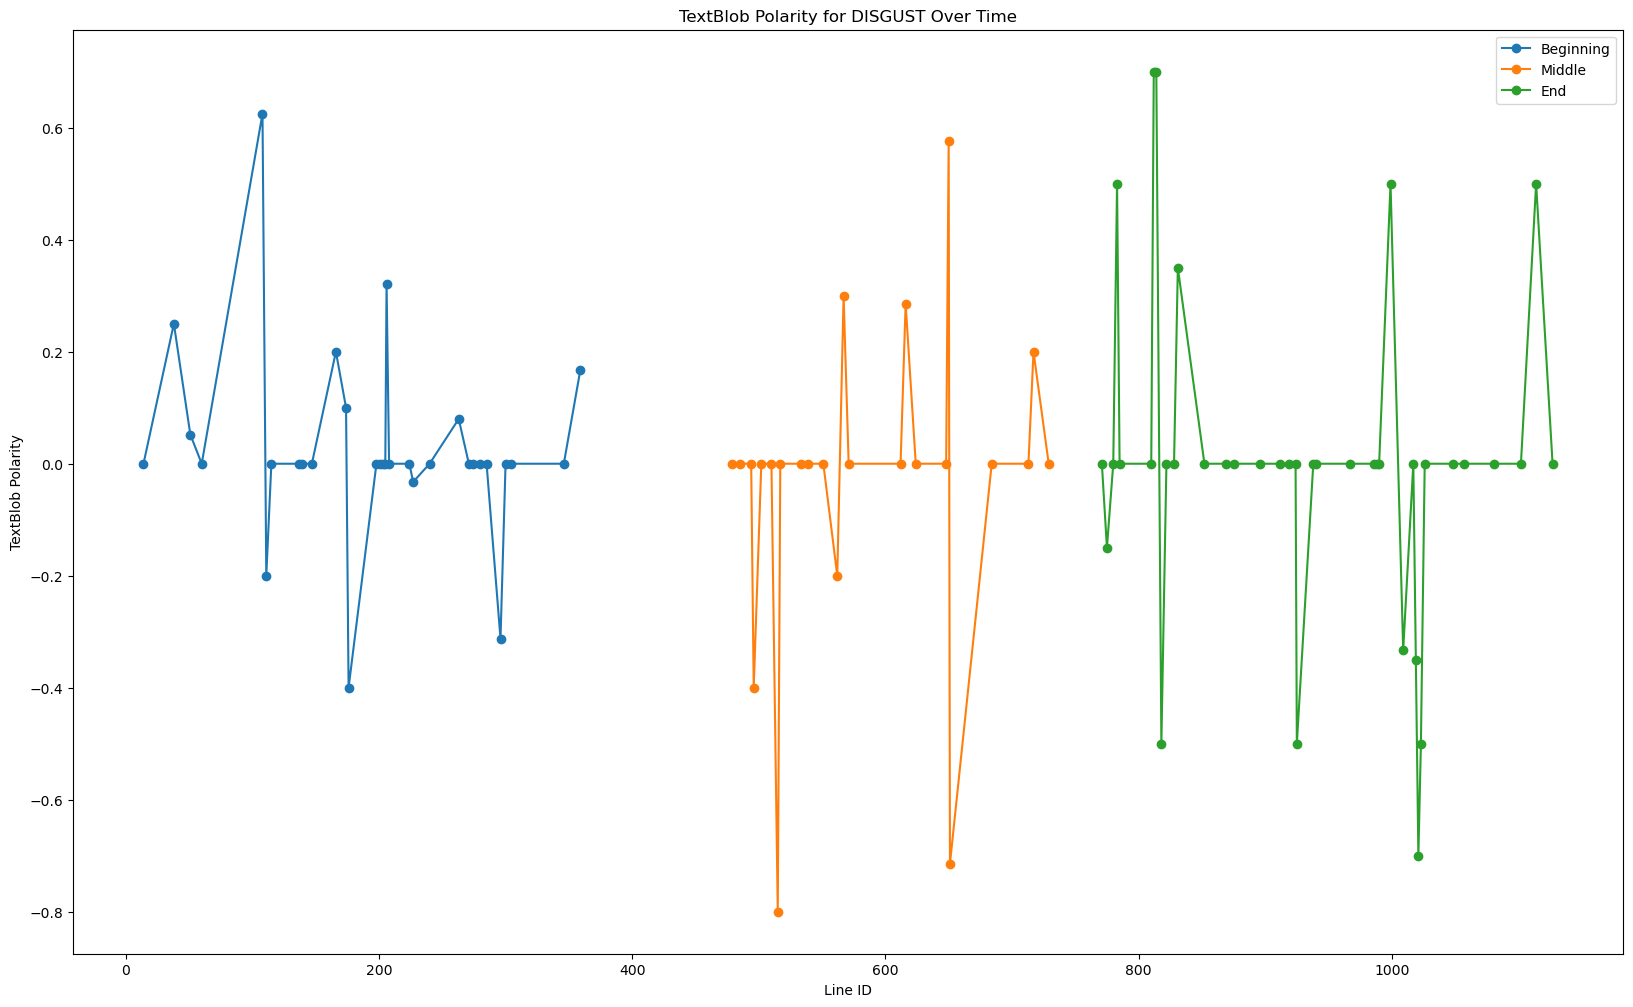

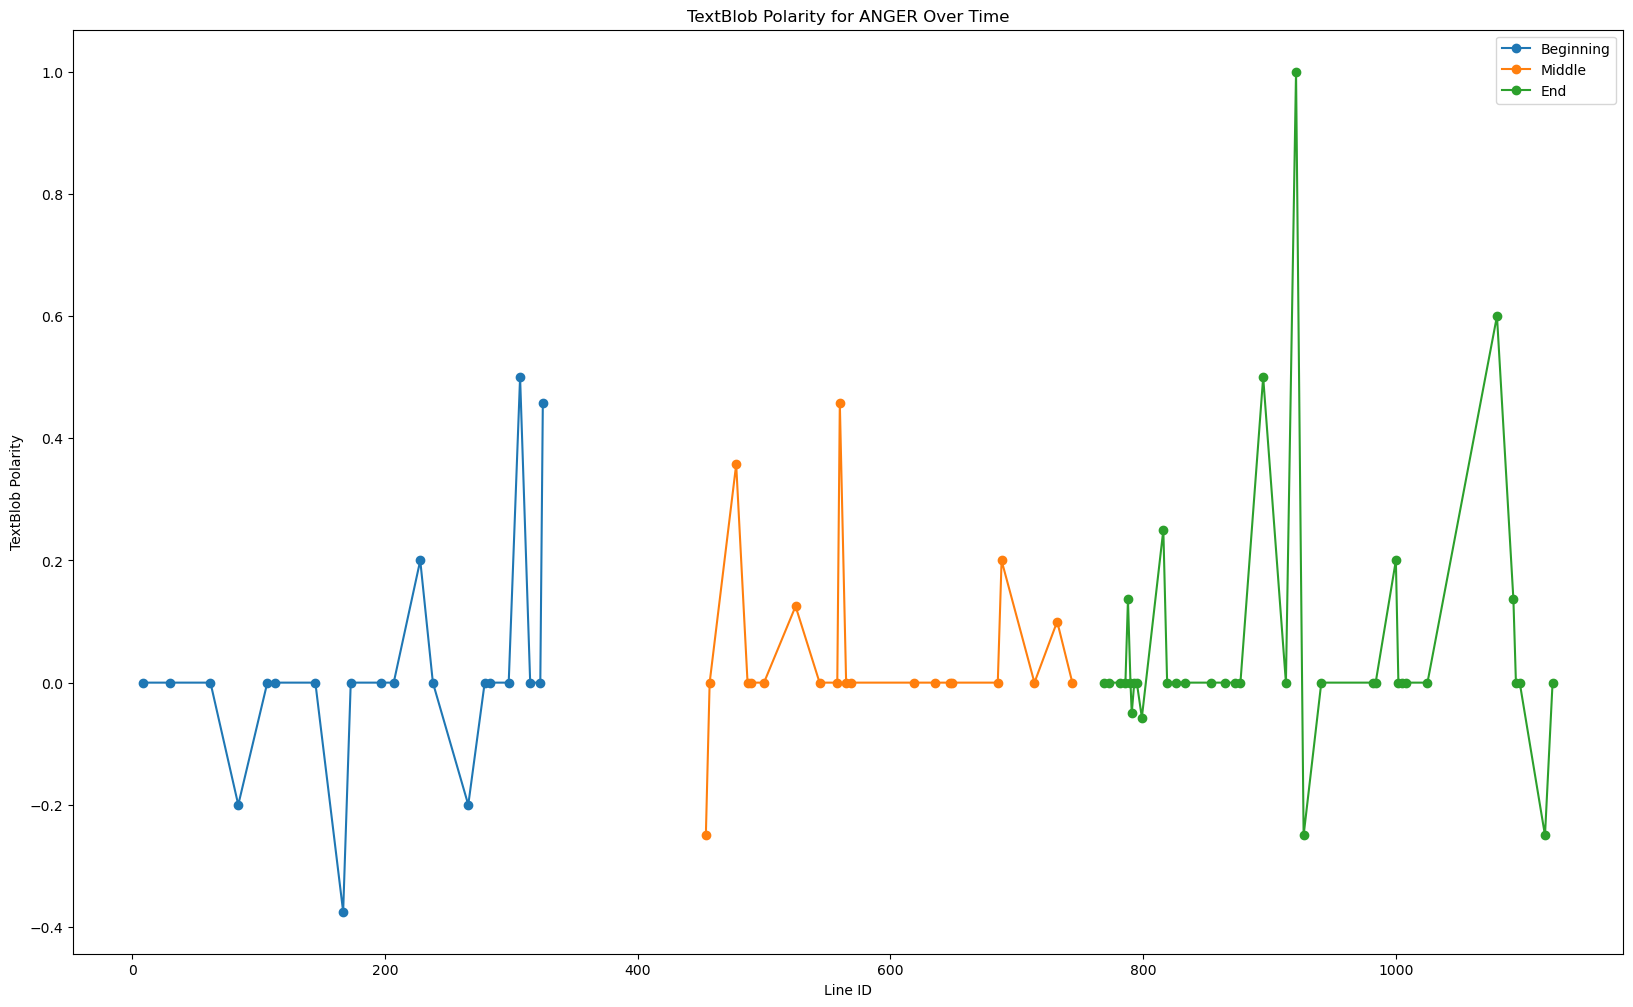

In [7]:
# Define the number of lines in each group
top_characters = ("JOY", "ANXIETY", "DISGUST", "ANGER")
total_lines = df['line_id'].max()
group_size = total_lines // 3
colors = {
    'JOY': 'yellow',
    'ANGER': 'red',
    'ANXIETY': 'orange',
    'DISGUST': 'green'
}


# Create a new column to indicate the group
df['group'] = pd.cut(df['line_id'], bins=[0, group_size, 2*group_size, total_lines], labels=['Beginning', 'Middle', 'End'])

# Filter the dataframe to include only the top 4 characters
filtered_df = df[df['character'].isin(top_characters)]

# Plot the TextBlob polarity for each of the top 4 characters over the three groups
plt.figure(figsize=(20, 12))
for character in top_characters:
    character_df = filtered_df[filtered_df['character'] == character]
    group_means = character_df.groupby('group')['TextBlob_polarity'].mean()
    plt.plot(group_means.index, group_means.values, marker='o', label=character, color=colors.get(character, 'black'))

plt.xlabel('Group')
plt.ylabel('TextBlob Polarity')
plt.title('TextBlob Polarity for Top 4 Characters Over Time')
plt.legend()
plt.show()

# Create individual plots for each character broken down by line_id for beginning, middle, and end
for character in top_characters:
    character_df = filtered_df[filtered_df['character'] == character]
    plt.figure(figsize=(20, 12))
    for group in ['Beginning', 'Middle', 'End']:
        group_df = character_df[character_df['group'] == group]
        plt.plot(group_df['line_id'], group_df['TextBlob_polarity'], marker='o', label=group)
    
    plt.xlabel('Line ID')
    plt.ylabel('TextBlob Polarity')
    plt.title(f'TextBlob Polarity for {character} Over Time')
    plt.legend()
    plt.show()